<a href="https://colab.research.google.com/github/Kushal-V/ML_practice/blob/LR/Linear_Regression_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Regression

Regression is a **supervised learning** technique used to model the relationship between a **dependent variable (target)** and one or more **independent variables (features)**.

### Types of Regression:
1. **Simple Linear Regression:**  
   - One independent variable (X)  
   - Equation:  Ŷ = b₀ + b₁X  
   - Example: Predicting temperature based on humidity

2. **Multiple Linear Regression:**  
   - Multiple independent variables (X₁, X₂, X₃, …)  
   - Equation: Ŷ = b₀ + b₁X₁ + b₂X₂ + … + bₙXₙ  
   - Example: Predicting temperature using humidity, wind speed, visibility, and pressure

We’ll explore both types step by step using weather data. *[Dataset Link](https://https://drive.google.com/drive/folders/12-Yod1dZRdvMmPFZ8n8KO1jUZELXTRaw?usp=sharing)*


# 🌦️ Linear Regression with Weather Data

### Topics Covered:
1. Understanding Linear Regression  
2. Implementing Linear Regression *from scratch (no libraries)*  
3. Using Scikit-learn for Simple & Multiple Linear Regression  
4. Practice Exercises  



## 📘 Understanding Linear Regression

Linear Regression tries to establish a **linear relationship** between a dependent variable (Y) and one or more independent variables (X).

The equation for simple linear regression:

\[
Y = mX + b
\]

Where:
- **m** = slope (change in Y for one unit change in X)
- **b** = intercept (Y value when X = 0)

The goal is to find *m* and *b* such that the prediction error (difference between actual and predicted Y) is minimized.


## 🔧 Implementing Linear Regression from Scratch (No Library)

We'll compute slope (*m*) and intercept (*b*) using the formulas:

\[
m = \frac{n(\sum xy) - (\sum x)(\sum y)}{n(\sum x^2) - (\sum x)^2}
\]
\[
b = \frac{(\sum y) - m(\sum x)}{n}
\]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/weatherHistory.csv")

X = data['Humidity'].values[:100]
Y = data['Apparent Temperature (C)'].values[:100]

n = len(X)
m = (n*(X*Y).sum() - X.sum()*Y.sum()) / (n*(X**2).sum() - (X.sum())**2)
b = (Y.sum() - m*X.sum()) / n

print(f"Slope (m): {m}")
print(f"Intercept (b): {b}")

def predict(x):
    return m*x + b

x_test = 0.75
print(f"Predicted Apparent Temperature for Humidity={x_test}: {predict(x_test):.2f} °C")

Slope (m): -27.279199395678283
Intercept (b): 30.766928057836925
Predicted Apparent Temperature for Humidity=0.75: 10.31 °C


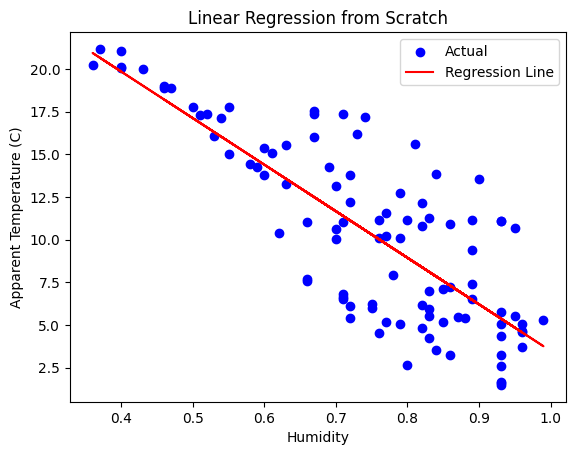

In [9]:
import matplotlib.pyplot as plt

plt.scatter(X, Y, color='blue', label='Actual')
plt.plot(X, predict(X), color='red', label='Regression Line')
plt.xlabel('Humidity')
plt.ylabel('Apparent Temperature (C)')
plt.legend()
plt.title('Linear Regression from Scratch')
plt.show()

## 🧠 Practice 1
Implement the above formula using **NumPy vectorization** instead of manual loops.  
Try predicting the apparent temperature for humidity values `[0.5, 0.6, 0.8]`.


In [10]:
import numpy as np

n = X.shape[0]

m = (n * np.sum(X * Y) - np.sum(X) * np.sum(Y)) / \
    (n * np.sum(X**2) - (np.sum(X))**2)

b = (np.sum(Y) - m * np.sum(X)) / n

print(f"Slope (m): {m}")
print(f"Intercept (b): {b}")


Slope (m): -27.279199395678283
Intercept (b): 30.766928057836925


In [11]:
humidity_values = np.array([0.5, 0.6, 0.8])

predictions = predict(humidity_values)

for h, temp in zip(humidity_values, predictions):
    print(f"Humidity = {h} → Predicted Apparent Temperature = {temp:.2f} °C")


Humidity = 0.5 → Predicted Apparent Temperature = 17.13 °C
Humidity = 0.6 → Predicted Apparent Temperature = 14.40 °C
Humidity = 0.8 → Predicted Apparent Temperature = 8.94 °C


## 🧩 Implementing Linear Regression using Scikit-Learn

Now that we understand the math, let’s use `LinearRegression` from sklearn to:
1. Train a model on humidity vs. apparent temperature  
2. Predict for new humidity values  
3. Compare results with our from-scratch implementation


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Prepare data
X = data[['Humidity']]
y = data['Apparent Temperature (C)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

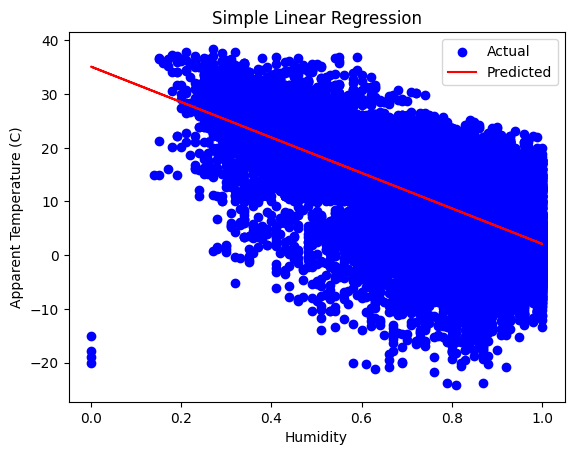

In [13]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Humidity')
plt.ylabel('Apparent Temperature (C)')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

## 🧠 Practice 2
- Predict *Apparent Temperature* for humidity = 0.65 and 0.80.  
- Plot the regression line on the full dataset (not just test data).


In [16]:
X = data[['Humidity']]
y = data['Apparent Temperature (C)']

model = LinearRegression()
model.fit(X, y)

humidity_values = np.array([[0.65], [0.80]])

predicted_temps = model.predict(humidity_values)

for h, t in zip(humidity_values.flatten(), predicted_temps):
    print(f"Humidity = {h} → Predicted Apparent Temperature = {t:.2f} °C")


Humidity = 0.65 → Predicted Apparent Temperature = 13.65 °C
Humidity = 0.8 → Predicted Apparent Temperature = 8.71 °C


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


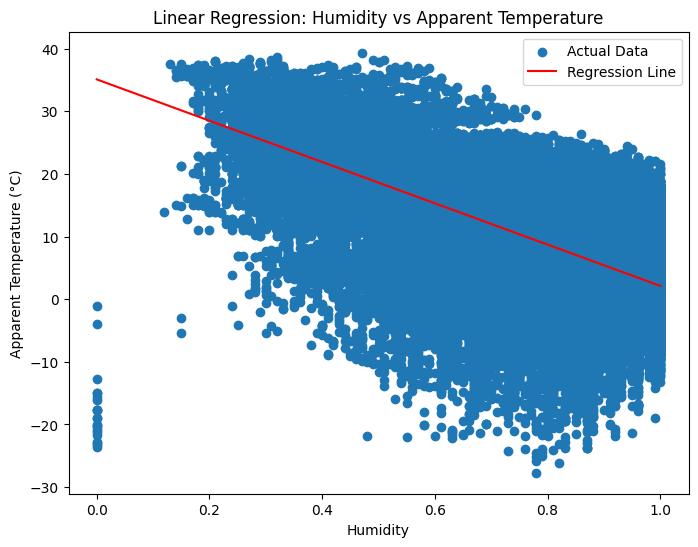

In [19]:
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

y_line = model.predict(X_line)

plt.figure(figsize=(8,6))

plt.scatter(X, y, label="Actual Data")
plt.plot(X_line, y_line, color='red', label="Regression Line")
plt.xlabel("Humidity")
plt.ylabel("Apparent Temperature (°C)")
plt.title("Linear Regression: Humidity vs Apparent Temperature")
plt.legend()
plt.show()



# 📊 Multiple Linear Regression

In multiple regression, we use **multiple predictors** to predict a single target variable.

\[
Y = b_0 + b_1X_1 + b_2X_2 + ... + b_nX_n
\]

We’ll predict *Apparent Temperature (C)* using:
- Temperature (C)  
- Humidity  
- Wind Speed (km/h)  
- Visibility (km)  
- Pressure (millibars)


In [20]:
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']
X_multi = data[features]
y_multi = data['Apparent Temperature (C)']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

In [21]:
print("R² Score:", r2_score(y_test, y_pred_multi))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_multi)))

coeffs = pd.DataFrame(multi_model.coef_, features, columns=['Coefficient'])
coeffs

R² Score: 0.9899302164737046
RMSE: 1.0793802398662602


,Coefficient
Temperature (C),1.125729
Humidity,1.046840
Wind Speed (km/h),-0.094695
Visibility (km),-0.000506
Pressure (millibars),0.000198


## 🧠 Exercise 3
Predict *Apparent Temperature* when:

| Temperature (C) | Humidity | Wind Speed (km/h) | Visibility (km) | Pressure (millibars) |
|------------------|----------|------------------|-----------------|---------------------|
| 12 | 0.65 | 10 | 9 | 1015 |


In [22]:
sample = np.array([[12, 0.65, 10, 9, 1015]])
multi_model.predict(sample)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([10.9243724])

## 🧠 Practice 4
1. Train your own model using any **subset of features** (e.g., only Humidity, Wind Speed, Pressure).  
2. Evaluate which combination gives the **highest R² score**.  
3. Interpret the meaning of coefficients — which features affect apparent temperature most?


In [23]:
y = data['Apparent Temperature (C)']

def train_and_evaluate(features):
    X = data[features]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)

    return score, model


In [25]:
features_1 = ['Humidity']
r2_1, model_1 = train_and_evaluate(features_1)

print("Features:", features_1)
print("R² score:", r2_1)

features_2 = ['Humidity', 'Wind Speed (km/h)']
r2_2, model_2 = train_and_evaluate(features_2)

print("Features:", features_2)
print("R² score:", r2_2)

features_3 = ['Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
r2_3, model_3 = train_and_evaluate(features_3)

print("Features:", features_3)
print("R² score:", r2_3)

features_4 = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']
r2_4, model_4 = train_and_evaluate(features_4)

print("Features:", features_4)
print("R² score:", r2_4)

features_5 = ['Temperature (C)','Humidity','Wind Speed (km/h)','Visibility (km)','Pressure (millibars)']
r2_5, model_5 = train_and_evaluate(features_5)

print("Features:", features_5)
print("R² score:", r2_5)



Features: ['Humidity']
R² score: 0.3587532329296208
Features: ['Humidity', 'Wind Speed (km/h)']
R² score: 0.3978063026358415
Features: ['Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
R² score: 0.39783232913726574
Features: ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']
R² score: 0.9899264223874612
Features: ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']
R² score: 0.9899302164737046


In [26]:
# here temperature is effecting the most as we can see the jump in R2 score in the 4th model run.